In [1]:
import numpy as np
import xarray as xr
from matplotlib import pyplot as plt
import matplotlib as mpl
import pandas as pd
import cartopy.crs as ccrs
import os
import datetime
from datetime import timedelta
from matplotlib import ticker
from matplotlib.axes import Axes
import matplotlib
from cartopy.mpl.geoaxes import GeoAxes
import cartopy.feature as cfeature
import matplotlib.patheffects as pe
from matplotlib.lines import Line2D
from scipy import stats
import scipy
import matplotlib.dates as mdates
from matplotlib.offsetbox import AnchoredOffsetbox, TextArea, HPacker, VPacker
import shapefile as shp
import matplotlib.patches as patches
#from tqdm import tqdm

import warnings
warnings.filterwarnings("ignore")

GeoAxes._pcolormesh_patched = Axes.pcolormesh

In [2]:
def weekly_sum(data):
    
    weekly_list = []
    
    for year in np.unique(data["time.year"]):
        start = pd.Timestamp(f"{year}-01-01")
        end = pd.Timestamp(f"{year}-12-31")
    
        da_year = data.sel(time=slice(start, end))
    
        # Define 7-day bins starting Jan 1, ending Dec 31
        bin_edges = pd.date_range(start, end + pd.Timedelta(days=7), freq="7D")
    
        # Group days into those bins
        weekly_year = da_year.groupby_bins("time", bins=bin_edges, right=False).sum()
    
        # Rename the resulting coordinate so we can use it as "time"
        weekly_year = weekly_year.rename({"time_bins": "time"})
    
        # Set the coordinate values to the left bin edges (start of week)
        weekly_year = weekly_year.assign_coords(time=bin_edges[:-1])
    
        weekly_list.append(weekly_year)
    
    # Concatenate all years together
    weekly = xr.concat(weekly_list, dim="time")

    return weekly

In [3]:
def resample_with_replacement(group):
    
    # Determine the size of the group
    group_size = group.sizes['time']

    # Generate random indices with replacement
    random_indices = np.random.choice(group_size, size=group_size, replace=True)
    
    # Select data using the random indices
    resampled_data = group.isel(time=random_indices)
    
    return resampled_data

In [4]:
# Open real land mask
frac_land = xr.open_dataset('/discover/nobackup/projects/gmao/merra2/data/products/MERRA2_all/MERRA2.const_2d_ctm_Nx.00000000.nc4').FRLAND

land_mask = xr.where(frac_land.mean(dim = 'time') > 0.5, 1, np.nan)
land_mask.load();

mask_array = land_mask.to_numpy()

In [5]:
# Import two data files
save_dir = '/discover/nobackup/civanovi/data/MERRA2/processed_data/'

T95_days_daily = xr.open_dataarray(save_dir + 'global_T95_days_daily_count_1980-1989_baseperiod.nc')
WBGT95_days_daily = xr.open_dataarray(save_dir + 'global_WBGT95_days_daily_count_1980-1989_baseperiod.nc')

In [6]:
# Save out text files
save_dir = '/discover/nobackup/civanovi/data/MERRA2/processed_data/'

mid_month_WBGT = np.loadtxt(save_dir + 'middlemonth_3month_highestWBGT95_1980-1989_baseperiod.txt', delimiter=',')
mid_month_T = np.loadtxt(save_dir + 'middlemonth_3month_highestT95_1980-1989_baseperiod.txt', delimiter=',')

mid_month_WBGT_ds = xr.DataArray(mid_month_WBGT, 
                                coords={'lat': T95_days_daily.lat,'lon': T95_days_daily.lon}, 
                                dims=["lat", "lon"])

mid_month_T_ds = xr.DataArray(mid_month_T, 
                                coords={'lat': T95_days_daily.lat,'lon': T95_days_daily.lon}, 
                                dims=["lat", "lon"])

In [7]:
# Select early and late periods
period_names = ['Early Period: 1980-1989','Late Period: 2015-2024']
early_period = ['1980-01-01','1989-12-31']
late_period = ['2015-01-01','2024-12-31']

T95_early = T95_days_daily.sel(time = slice(early_period[0],early_period[1]))
T95_late = T95_days_daily.sel(time = slice(late_period[0],late_period[1]))

WBGT95_early = WBGT95_days_daily.sel(time = slice(early_period[0],early_period[1]))
WBGT95_late = WBGT95_days_daily.sel(time = slice(late_period[0],late_period[1]))

In [8]:
# Select early and late periods
period_names = ['Early Period: 1980-1989','Late Period: 2015-2024']
early_period = ['1980-01-01','1989-12-31']
late_period = ['2015-01-01','2024-12-31']

T95_early = T95_days_daily.sel(time = slice(early_period[0],early_period[1]))
T95_early_total = T95_early.sum(dim = 'time')

T95_late = T95_days_daily.sel(time = slice(late_period[0],late_period[1]))
T95_late_total = T95_late.sum(dim = 'time')

WBGT95_early = WBGT95_days_daily.sel(time = slice(early_period[0],early_period[1]))
WBGT95_early_total = WBGT95_early.sum(dim = 'time')

WBGT95_late = WBGT95_days_daily.sel(time = slice(late_period[0],late_period[1]))
WBGT95_late_total = WBGT95_late.sum(dim = 'time')

# Calculations

In [10]:
# Define a function that returns change in mean, skewness, and kurtosis
def distribution_shifts_weekly(early_data,late_data, dist_type: str):

    dist_types = ['counts', 'frac']
    
    if dist_type not in dist_types:
        raise ValueError("Invalid distribution type. Expected one of: %s" % dist_types)

    # At each location, record the week when each extreme event happened
    early_counts = early_data.where(early_data > 0, drop = True).time.dt.week
    late_counts = late_data.where(late_data > 0, drop = True).time.dt.week

    early_total = early_counts.sum(dim = 'time')
    early_frac = early_counts/early_total

    late_total = late_counts.sum(dim = 'time')
    late_frac = late_counts/late_total

    # Set which one you use based on calculation type
    if dist_type == 'counts':
        early_period = early_counts
        late_period = late_counts
    elif dist_type == 'frac':
        early_period = early_frac
        late_period = late_frac
        
    peak_period = stats.mode(early_period.values).mode

    # Only do this where it works
    if (peak_period - peak_period) == 0:

        # Subtract peak month
        early_period_temp = np.array([x - int(peak_period) for x in early_period.values])
        late_period_temp = np.array([x - int(peak_period) for x in late_period.values])

        # Account for annual cycle numbering convention
        early_period_shifted = [
            (x-52) if x > 26 else
            (x+52) if x < -26 else
            x
            for x in early_period_temp
        ]
        
        late_period_shifted = [
            (x-52) if x > 26 else
            (x+52) if x < -26 else
            x
            for x in late_period_temp
        ]

        if (len(early_period_temp) > 0) & (len(late_period_temp) > 0):
        
            # Calculate changes in distributions
            #mean_shift = np.mean(late_period_shifted) - np.mean(early_period_shifted)
            #skew_shift = stats.skew(late_period_shifted) - stats.skew(early_period_shifted)
            #kurtosis_shift = stats.kurtosis(late_period_shifted) - stats.kurtosis(early_period_shifted)
            #median_shift = np.median(late_period_shifted) - np.median(early_period_shifted)
            #variance_shift = np.var(late_period_shifted) - np.var(early_period_shifted)
            std_shift = np.std(late_period_shifted) - np.std(early_period_shifted)
            #iqr_shift = stats.iqr(late_period_shifted) - stats.iqr(early_period_shifted)

        else:
            #mean_shift = np.nan
            #median_shift = np.nan
            #skew_shift = np.nan
            #kurtosis_shift = np.nan
            #variance_shift = np.nan
            std_shift = np.nan
            #iqr_shift = np.nan

    else:
        #mean_shift = np.nan
        #median_shift = np.nan
        #skew_shift = np.nan
        #kurtosis_shift = np.nan
        #variance_shift = np.nan
        std_shift = np.nan
        #iqr_shift = np.nan
    
    return std_shift #np.array([mean_shift, median_shift, skew_shift, kurtosis_shift, variance_shift, iqr_shift])

In [10]:
# Define a function that returns change in mean, skewness, and kurtosis
def distribution_shifts_weekly_pvalues(early_data,late_data, dist_type: str):

    dist_types = ['counts', 'frac']
    
    if dist_type not in dist_types:
        raise ValueError("Invalid distribution type. Expected one of: %s" % dist_types)

    # At each location, record the week when each extreme event happened
    early_counts = early_data.where(early_data > 0, drop = True).time.dt.week
    late_counts = late_data.where(late_data > 0, drop = True).time.dt.week

    early_total = early_counts.sum(dim = 'time')
    early_frac = early_counts/early_total

    late_total = late_counts.sum(dim = 'time')
    late_frac = late_counts/late_total

    # Set which one you use based on calculation type
    if dist_type == 'counts':
        early_period = early_counts
        late_period = late_counts
    elif dist_type == 'frac':
        early_period = early_frac
        late_period = late_frac
        
    peak_period = stats.mode(early_period.values).mode

    # Only do this where it works
    if (peak_period - peak_period) == 0:

        # Subtract peak month
        early_period_temp = np.array([x - int(peak_period) for x in early_period.values])
        late_period_temp = np.array([x - int(peak_period) for x in late_period.values])

        # Account for annual cycle numbering convention
        early_period_shifted = [
            (x-52) if x > 26 else
            (x+52) if x < -26 else
            x
            for x in early_period_temp
        ]
        
        late_period_shifted = [
            (x-52) if x > 26 else
            (x+52) if x < -26 else
            x
            for x in late_period_temp
        ]

        if (len(early_period_temp) > 0) & (len(late_period_temp) > 0):
        
            # Calculate significance of changes
            mean_shift_pval = stats.ttest_ind(late_period_shifted, early_period_shifted, equal_var=False, alternative='two-sided').pvalue
            median_shift_pval = stats.ranksums(late_period_shifted, early_period_shifted, alternative = 'two-sided').pvalue
            variance_shift_pval = stats.levene(late_period_shifted, early_period_shifted).pvalue
            iqr_shift_pval = stats.ansari(late_period_shifted, early_period_shifted, alternative='two-sided').pvalue

        else:
            mean_shift_pval = np.nan
            median_shift_pval = np.nan
            variance_shift_pval = np.nan
            iqr_shift_pval = np.nan

    else:
        mean_shift_pval = np.nan
        median_shift_pval = np.nan
        variance_shift_pval = np.nan
        iqr_shift_pval = np.nan
    
    return np.array([mean_shift_pval, median_shift_pval, variance_shift_pval,iqr_shift_pval])

In [11]:
#mean_shifts_T95 = np.zeros((np.shape(T95_early)[1],np.shape(T95_early)[2]))
#median_shifts_T95 = np.zeros((np.shape(T95_early)[1],np.shape(T95_early)[2]))
#skew_shifts_T95 = np.zeros((np.shape(T95_early)[1],np.shape(T95_early)[2]))
#kurtosis_shifts_T95 = np.zeros((np.shape(T95_early)[1],np.shape(T95_early)[2]))
#var_shifts_T95 = np.zeros((np.shape(T95_early)[1],np.shape(T95_early)[2]))
#iqr_shifts_T95 = np.zeros((np.shape(T95_early)[1],np.shape(T95_early)[2]))
std_shifts_T95 = np.zeros((np.shape(T95_early)[1],np.shape(T95_early)[2]))
                      
# Loop through grid cells and calculate
for i in tqdm(range(np.shape(T95_early)[1])):
    for j in range(np.shape(T95_early)[2]):

        early_data_gc = T95_early.isel(lat = i, lon = j)
        late_data_gc = T95_late.isel(lat = i, lon = j)

        #[mean_shift, median_shift, skew_shift, kurtosis_shift, var_shift, iqr_shift] = distribution_shifts_weekly(early_data_gc,late_data_gc, dist_type = 'counts')
        std_shift = distribution_shifts_weekly(early_data_gc,late_data_gc, dist_type = 'counts')
        
        #mean_shifts_T95[i,j] = mean_shift
        #median_shifts_T95[i,j] = median_shift
        #skew_shifts_T95[i,j] = skew_shift
        #kurtosis_shifts_T95[i,j] = kurtosis_shift
        #var_shifts_T95[i,j] = var_shift
        #iqr_shifts_T95[i,j] = iqr_shift
        std_shifts_T95[i,j] = std_shift

#mean_shifts_WBGT95 = np.zeros((np.shape(WBGT95_early)[1],np.shape(WBGT95_early)[2]))
#median_shifts_WBGT95 = np.zeros((np.shape(WBGT95_early)[1],np.shape(WBGT95_early)[2]))
#skew_shifts_WBGT95 = np.zeros((np.shape(WBGT95_early)[1],np.shape(WBGT95_early)[2]))
#kurtosis_shifts_WBGT95 = np.zeros((np.shape(WBGT95_early)[1],np.shape(WBGT95_early)[2]))
#var_shifts_WBGT95 = np.zeros((np.shape(WBGT95_early)[1],np.shape(WBGT95_early)[2]))
#iqr_shifts_WBGT95 = np.zeros((np.shape(WBGT95_early)[1],np.shape(WBGT95_early)[2]))
std_shifts_WBGT95 = np.zeros((np.shape(WBGT95_early)[1],np.shape(WBGT95_early)[2]))
                      
# Loop through grid cells and calculate
for i in tqdm(range(np.shape(WBGT95_early)[1])):
    for j in range(np.shape(WBGT95_early)[2]):

        early_data_gc = WBGT95_early.isel(lat = i, lon = j)
        late_data_gc = WBGT95_late.isel(lat = i, lon = j)

        #[mean_shift, median_shift, skew_shift, kurtosis_shift, var_shift, iqr_shift] = distribution_shifts_weekly(early_data_gc,late_data_gc, dist_type = 'counts')
        std_shift = distribution_shifts_weekly(early_data_gc,late_data_gc, dist_type = 'counts')
        
        #mean_shifts_WBGT95[i,j] = mean_shift
        #median_shifts_WBGT95[i,j] = median_shift
        #skew_shifts_WBGT95[i,j] = skew_shift
        #kurtosis_shifts_WBGT95[i,j] = kurtosis_shift
        #var_shifts_WBGT95[i,j] = var_shift
        #iqr_shifts_WBGT95[i,j] = iqr_shift
        std_shifts_WBGT95[i,j] = std_shift

100%|██████████| 361/361 [32:51<00:00,  5.46s/it]


In [12]:
# Save these out as text files
save_dir = '/discover/nobackup/civanovi/data/MERRA2/processed_data/npp_project2/baseperiod_1980s'

#np.savetxt(save_dir + 'weekly_T95_mean_shift_1980-1989_2015-2024.txt', mean_shifts_T95, delimiter=',')
#np.savetxt(save_dir + 'weekly_T95_skew_shift_1980-1989_2015-2024.txt', skew_shifts_T95, delimiter=',')
#np.savetxt(save_dir + 'weekly_T95_kurtosis_shift_1980-1989_2015-2024.txt', kurtosis_shifts_T95, delimiter=',')
#np.savetxt(save_dir + 'weekly_T95_median_shift_1980-1989_2015-2024.txt', median_shifts_T95, delimiter=',')
#np.savetxt(save_dir + 'weekly_T95_variance_shift_1980-1989_2015-2024.txt', var_shifts_T95, delimiter=',')
#np.savetxt(save_dir + 'weekly_T95_iqr_shift_1980-1989_2015-2024.txt', iqr_shifts_T95, delimiter=',')
np.savetxt(save_dir + 'weekly_T95_std_shift_1980-1989_2015-2024.txt', std_shifts_T95, delimiter=',')

#np.savetxt(save_dir + 'weekly_WBGT95_mean_shift_1980-1989_2015-2024.txt', mean_shifts_WBGT95, delimiter=',')
#np.savetxt(save_dir + 'weekly_WBGT95_skew_shift_1980-1989_2015-2024.txt', skew_shifts_WBGT95, delimiter=',')
#np.savetxt(save_dir + 'weekly_WBGT95_kurtosis_shift_1980-1989_2015-2024.txt', kurtosis_shifts_WBGT95, delimiter=',')
#np.savetxt(save_dir + 'weekly_WBGT95_median_shift_1980-1989_2015-2024.txt', median_shifts_WBGT95, delimiter=',')
#np.savetxt(save_dir + 'weekly_WBGT95_variance_shift_1980-1989_2015-2024.txt', var_shifts_WBGT95, delimiter=',')
#np.savetxt(save_dir + 'weekly_WBGT95_iqr_shift_1980-1989_2015-2024.txt', iqr_shifts_WBGT95, delimiter=',')
np.savetxt(save_dir + 'weekly_WBGT95_std_shift_1980-1989_2015-2024.txt', std_shifts_WBGT95, delimiter=',')

In [ ]:
mean_shifts_pval_T95 = np.zeros((np.shape(T95_early)[1],np.shape(T95_early)[2]))
median_shifts_pval_T95 = np.zeros((np.shape(T95_early)[1],np.shape(T95_early)[2]))
var_shifts_pval_T95 = np.zeros((np.shape(T95_early)[1],np.shape(T95_early)[2]))
iqr_shifts_pval_T95 = np.zeros((np.shape(T95_early)[1],np.shape(T95_early)[2]))
                      
# Loop through grid cells and calculate
for i in tqdm(range(np.shape(T95_early)[1])):
    for j in range(np.shape(T95_early)[2]):

        early_data_gc = T95_early.isel(lat = i, lon = j)
        late_data_gc = T95_late.isel(lat = i, lon = j)

        [mean_shift_pval_T95, median_shift_pval_T95, var_shift_pval_T95, iqr_shift_pval_T95] = distribution_shifts_weekly_pvalues(early_data_gc,late_data_gc, dist_type = 'counts')
        
        mean_shifts_pval_T95[i,j] = mean_shift_pval_T95
        median_shifts_pval_T95[i,j] = median_shift_pval_T95
        var_shifts_pval_T95[i,j] = var_shift_pval_T95
        iqr_shifts_pval_T95[i,j] = iqr_shift_pval_T95

mean_shifts_pval_WBGT95 = np.zeros((np.shape(WBGT95_early)[1],np.shape(WBGT95_early)[2]))
median_shifts_pval_WBGT95 = np.zeros((np.shape(WBGT95_early)[1],np.shape(WBGT95_early)[2]))
var_shifts_pval_WBGT95 = np.zeros((np.shape(WBGT95_early)[1],np.shape(WBGT95_early)[2]))
iqr_shifts_pval_WBGT95 = np.zeros((np.shape(WBGT95_early)[1],np.shape(WBGT95_early)[2]))
                      
# Loop through grid cells and calculate
for i in tqdm(range(np.shape(WBGT95_early)[1])):
    for j in range(np.shape(WBGT95_early)[2]):

        early_data_gc = WBGT95_early.isel(lat = i, lon = j)
        late_data_gc = WBGT95_late.isel(lat = i, lon = j)

        [mean_shift_pval_WBGT95, median_shift_pval_WBGT95, var_shift_pval_WBGT95, iqr_shift_pval_WBGT95] = distribution_shifts_weekly_pvalues(early_data_gc,late_data_gc, dist_type = 'counts')
        
        mean_shifts_pval_WBGT95[i,j] = mean_shift_pval_WBGT95
        median_shifts_pval_WBGT95[i,j] = median_shift_pval_WBGT95
        var_shifts_pval_WBGT95[i,j] = var_shift_pval_WBGT95
        iqr_shifts_pval_WBGT95[i,j] = iqr_shift_pval_WBGT95

 43%|████▎     | 157/361 [18:16<24:51,  7.31s/it]

In [ ]:
# Save these out as text files
save_dir = '/discover/nobackup/civanovi/data/MERRA2/processed_data/npp_project2/baseperiod_1980s'

np.savetxt(save_dir + 'weekly_T95_mean_shift_pval_1980-1989_2015-2024.txt', mean_shifts_pval_T95, delimiter=',')
np.savetxt(save_dir + 'weekly_T95_median_shift_pval_1980-1989_2015-2024.txt', median_shifts_pval_T95, delimiter=',')
np.savetxt(save_dir + 'weekly_T95_variance_shift_pval_1980-1989_2015-2024.txt', var_shifts_pval_T95, delimiter=',')
np.savetxt(save_dir + 'weekly_T95_iqr_shift_pval_1980-1989_2015-2024.txt', iqr_shifts_pval_T95, delimiter=',')

np.savetxt(save_dir + 'weekly_WBGT95_mean_shift_pval_1980-1989_2015-2024.txt', mean_shifts_pval_WBGT95, delimiter=',')
np.savetxt(save_dir + 'weekly_WBGT95_median_shift_pval_1980-1989_2015-2024.txt', median_shifts_pval_WBGT95, delimiter=',')
np.savetxt(save_dir + 'weekly_WBGT95_variance_shift_pval_1980-1989_2015-2024.txt', var_shifts_pval_WBGT95, delimiter=',')
np.savetxt(save_dir + 'weekly_WBGT95_iqr_shift_pval_1980-1989_2015-2024.txt', iqr_shifts_pval_WBGT95, delimiter=',')

# Plot figures

In [9]:
shapefile_dir = '/gpfsm/dnb33/civanovi/data/cartopy_shape_files/'

coastlines = shp.Reader(shapefile_dir + 'ne_10m_coastline/ne_10m_coastline.shp')
states = shp.Reader(shapefile_dir + 'ne_10m_admin_1_states_provinces/ne_10m_admin_1_states_provinces.shp')

In [10]:
# Open data files
save_dir = '/discover/nobackup/civanovi/data/MERRA2/processed_data/npp_project2/baseperiod_1980s'

mean_shifts_T95 = np.loadtxt(save_dir + 'weekly_T95_mean_shift_1980-1989_2015-2024.txt', delimiter=',')
median_shifts_T95 = np.loadtxt(save_dir + 'weekly_T95_median_shift_1980-1989_2015-2024.txt', delimiter=',')
skew_shifts_T95 = np.loadtxt(save_dir + 'weekly_T95_skew_shift_1980-1989_2015-2024.txt', delimiter=',')
kurtosis_shifts_T95 = np.loadtxt(save_dir + 'weekly_T95_kurtosis_shift_1980-1989_2015-2024.txt', delimiter=',')
var_shifts_T95 = np.loadtxt(save_dir + 'weekly_T95_variance_shift_1980-1989_2015-2024.txt', delimiter=',')
iqr_shifts_T95 = np.loadtxt(save_dir + 'weekly_T95_iqr_shift_1980-1989_2015-2024.txt', delimiter=',')
std_shifts_T95 = np.loadtxt(save_dir + 'weekly_T95_std_shift_1980-1989_2015-2024.txt', delimiter=',')

mean_shifts_WBGT95 = np.loadtxt(save_dir + 'weekly_WBGT95_mean_shift_1980-1989_2015-2024.txt', delimiter=',')
median_shifts_WBGT95 = np.loadtxt(save_dir + 'weekly_WBGT95_median_shift_1980-1989_2015-2024.txt', delimiter=',')
skew_shifts_WBGT95 = np.loadtxt(save_dir + 'weekly_WBGT95_skew_shift_1980-1989_2015-2024.txt', delimiter=',')
kurtosis_shifts_WBGT95 = np.loadtxt(save_dir + 'weekly_WBGT95_kurtosis_shift_1980-1989_2015-2024.txt', delimiter=',')
var_shifts_WBGT95 = np.loadtxt(save_dir + 'weekly_WBGT95_variance_shift_1980-1989_2015-2024.txt', delimiter=',')
iqr_shifts_WBGT95 = np.loadtxt(save_dir + 'weekly_WBGT95_iqr_shift_1980-1989_2015-2024.txt', delimiter=',')
std_shifts_WBGT95 = np.loadtxt(save_dir + 'weekly_WBGT95_std_shift_1980-1989_2015-2024.txt', delimiter=',')

In [11]:
# Open data files
save_dir = '/discover/nobackup/civanovi/data/MERRA2/processed_data/npp_project2/baseperiod_1980s'

mean_shifts_pval_T95 = np.loadtxt(save_dir + 'weekly_T95_mean_shift_pval_1980-1989_2015-2024.txt', delimiter=',')
median_shifts_pval_T95 = np.loadtxt(save_dir + 'weekly_T95_median_shift_pval_1980-1989_2015-2024.txt', delimiter=',')
var_shifts_pval_T95 = np.loadtxt(save_dir + 'weekly_T95_variance_shift_pval_1980-1989_2015-2024.txt', delimiter=',')
iqr_shifts_pval_T95 = np.loadtxt(save_dir + 'weekly_T95_iqr_shift_pval_1980-1989_2015-2024.txt', delimiter=',')

mean_shifts_pval_WBGT95 = np.loadtxt(save_dir + 'weekly_WBGT95_mean_shift_pval_1980-1989_2015-2024.txt', delimiter=',')
median_shifts_pval_WBGT95 = np.loadtxt(save_dir + 'weekly_WBGT95_median_shift_pval_1980-1989_2015-2024.txt', delimiter=',')
var_shifts_pval_WBGT95 = np.loadtxt(save_dir + 'weekly_WBGT95_variance_shift_pval_1980-1989_2015-2024.txt', delimiter=',')
iqr_shifts_pval_WBGT95 = np.loadtxt(save_dir + 'weekly_WBGT95_iqr_shift_pval_1980-1989_2015-2024.txt', delimiter=',')

0.00030088240900794967


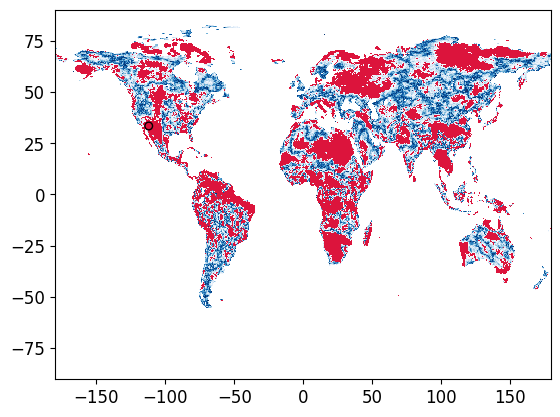

0.007932055786232028


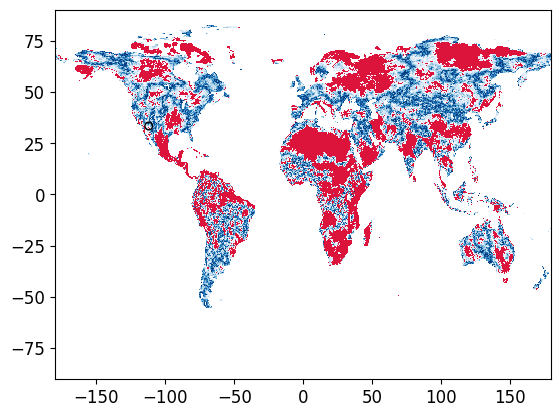

0.4613622922099436


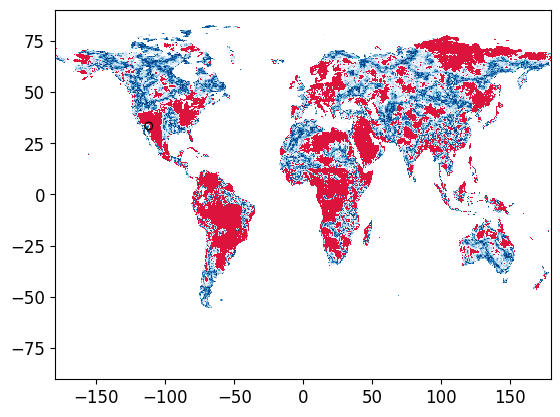

0.3351141087612196


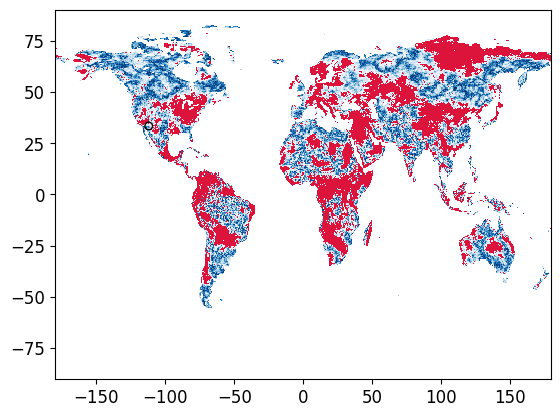

In [42]:
# Calculate Phoenix significance
location = 'PHOENIX'
lat = 33.4483
lon = -112.0725

pvals = [median_shifts_pval_T95,median_shifts_pval_WBGT95,iqr_shifts_pval_T95,iqr_shifts_pval_WBGT95]

for pval_set in pvals:
    pval_da = xr.DataArray(pval_set*mask_array,
                           coords={"lat": T95_days_daily.lat, "lon": T95_days_daily.lon},
                           dims=["lat", "lon"]
                          )
    pval_gc = pval_da.sel(lat = lat, lon = lon, method = 'nearest')
    print(pval_gc.values)

    cmap = plt.cm.get_cmap("Blues")
    cmap.set_under('crimson')
    
    plt.pcolormesh(pval_da.lon, pval_da.lat, pval_da, cmap = cmap, vmin = 0.05, vmax = 1)
    plt.scatter(lon, lat, marker = 'o', s = 30, edgecolor = 'k', facecolor = 'none')

    plt.show()

Error in callback <function _draw_all_if_interactive at 0x14ee834605e0> (for post_execute), with arguments args (),kwargs {}:


KeyboardInterrupt: 

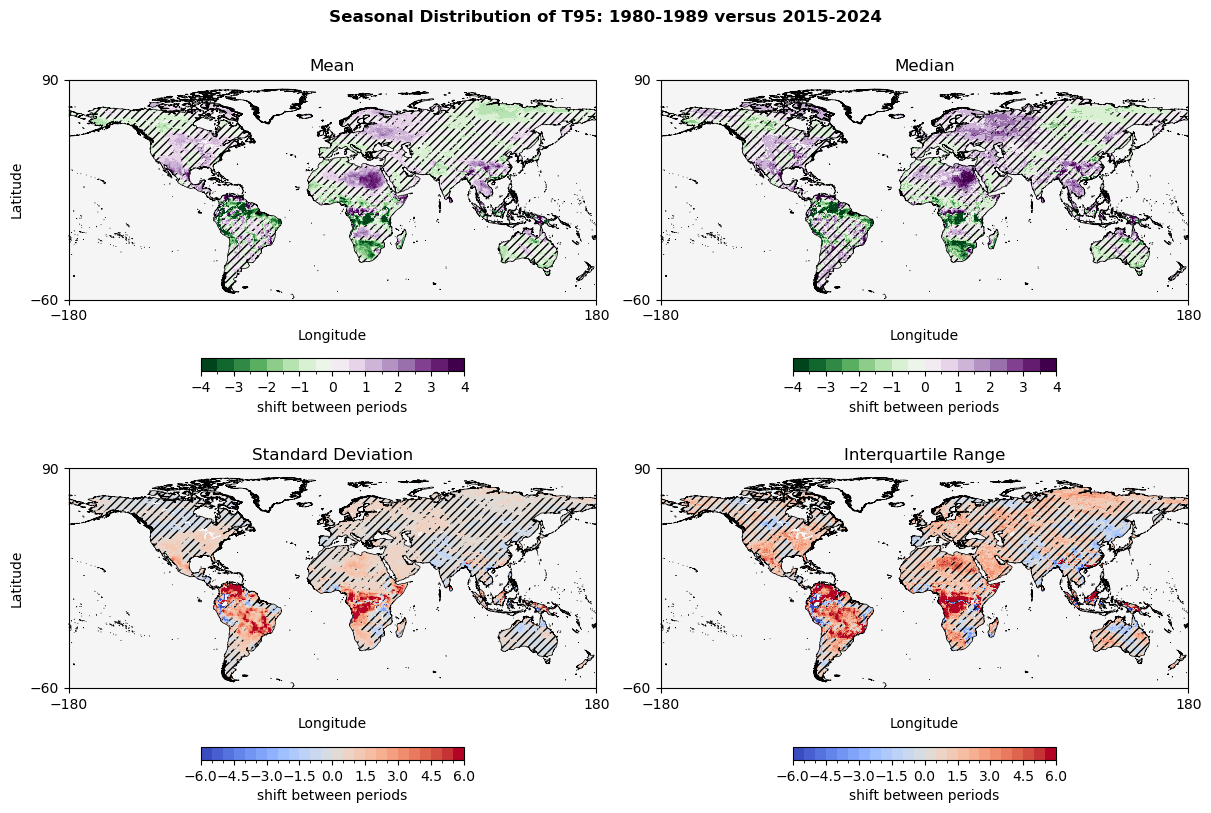

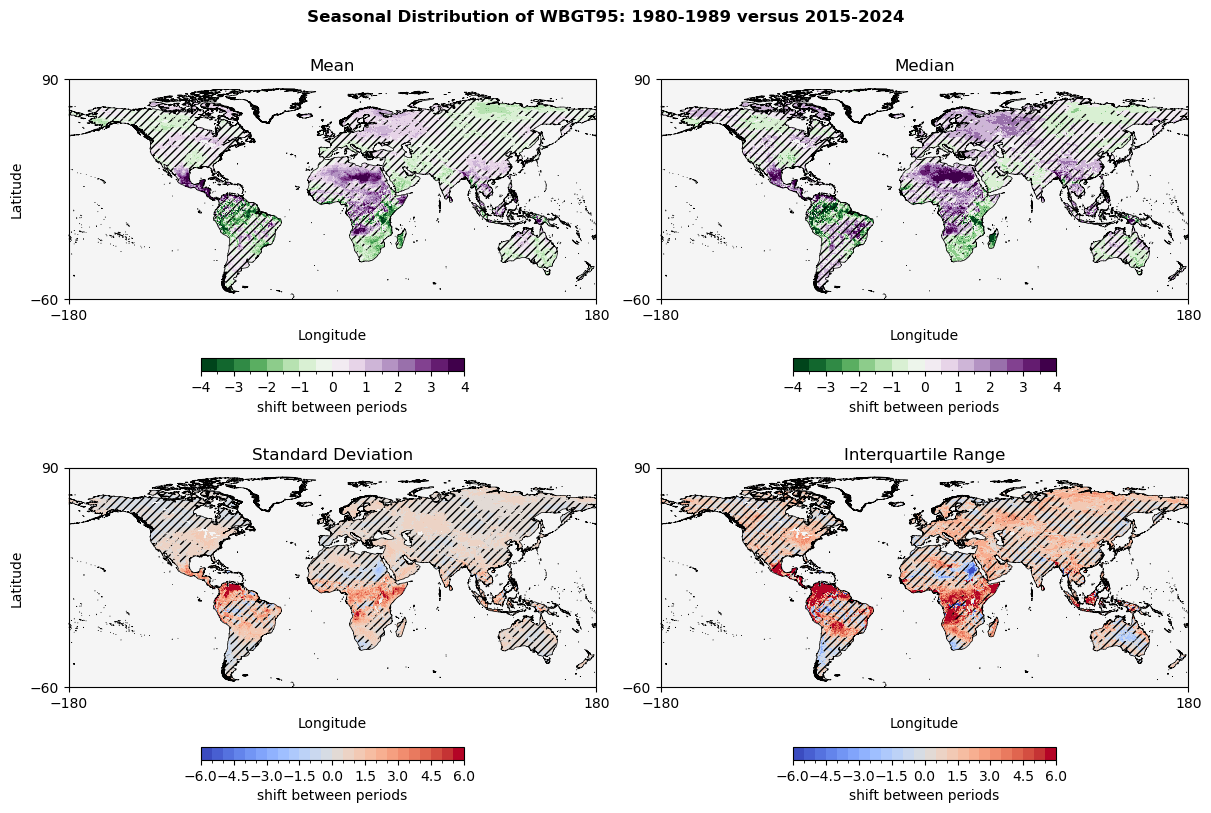

In [9]:
# Plot figures

reg_lats = [-60,90]
reg_lons = [-180,180]

min_sig = 0.05

T95_data = [mean_shifts_T95,median_shifts_T95, std_shifts_T95,iqr_shifts_T95]
WBGT95_data = [mean_shifts_WBGT95,median_shifts_WBGT95, std_shifts_WBGT95,iqr_shifts_WBGT95]

T95_sig = [mean_shifts_pval_T95,median_shifts_pval_T95,var_shifts_pval_T95,iqr_shifts_pval_T95]
WBGT95_sig = [mean_shifts_pval_WBGT95,median_shifts_pval_WBGT95,var_shifts_pval_WBGT95,iqr_shifts_pval_WBGT95]

titles = ['Mean','Median','Standard Deviation','Interquartile Range']

extremes_datasets = [T95_data,WBGT95_data]
sig_datasets = [T95_sig,WBGT95_sig]
extremes_titles = ['T95','WBGT95']

for j, extremes_data in enumerate(extremes_datasets):

    sig_data = sig_datasets[j]

    fig, axs = plt.subplots(2,2, figsize = (12,8),facecolor = 'w', edgecolor = 'k',constrained_layout=True, subplot_kw = {'projection': ccrs.PlateCarree()})
    
    for i, ax in enumerate(fig.axes):

        if i in [0,2]:
            ax.set_ylabel('Latitude')
        if i < 2:
            cmap = plt.cm.get_cmap("PRGn_r")
            bounds = np.arange(-4, 4.5, 0.5)
            
        if i > 1:
            cmap = plt.cm.get_cmap("coolwarm")
            bounds = np.arange(-6, 6.5, 0.5)
            
            #if i == 2:
            #    bounds = np.arange(-30, 40, 10)
            #else:
            #    bounds = np.arange(-6, 6.5, 0.5)
                
        norm = matplotlib.colors.BoundaryNorm(bounds, cmap.N)
        cmap.set_bad('whitesmoke',1.)

        # Plot shaded data
        data_masked = extremes_data[i]*mask_array
        mesh = ax.pcolormesh(frac_land.lon,frac_land.lat,data_masked, norm = norm, cmap = cmap)

        # Plot significance stipping
        sig_mask = (sig_data[i]*mask_array > 0.05)
        conf = ax.contourf(frac_land.lon, frac_land.lat, sig_mask, hatches=['', '////'], alpha=0)

        # Plot coastlines and states given cartopy not working
        for shape in coastlines.shapeRecords():
            x = [m[0] for m in shape.shape.points[:]]
            y = [m[1] for m in shape.shape.points[:]]
            ax.plot(x,y, color = 'k', linewidth = 0.5)
        
        ax.set_xlim(reg_lons)
        ax.set_ylim(reg_lats)
        ax.set_xticks(reg_lons);
        ax.set_yticks(reg_lats);
        ax.set_xlabel('Longitude')
        ax.set_title(titles[i])
    
        plt.colorbar(mesh, ax = ax, orientation = 'horizontal', shrink = 0.5, label = 'shift between periods')
    
    plt.suptitle(f'Seasonal Distribution of {extremes_titles[j]}: 1980-1989 versus 2015-2024', fontweight = 'bold', horizontalalignment = 'center')

        #if i == 3:
        #    ax.remove()

# Plot combined figure for T and WBGT

Only plotting median and interquartile range to match figure 1

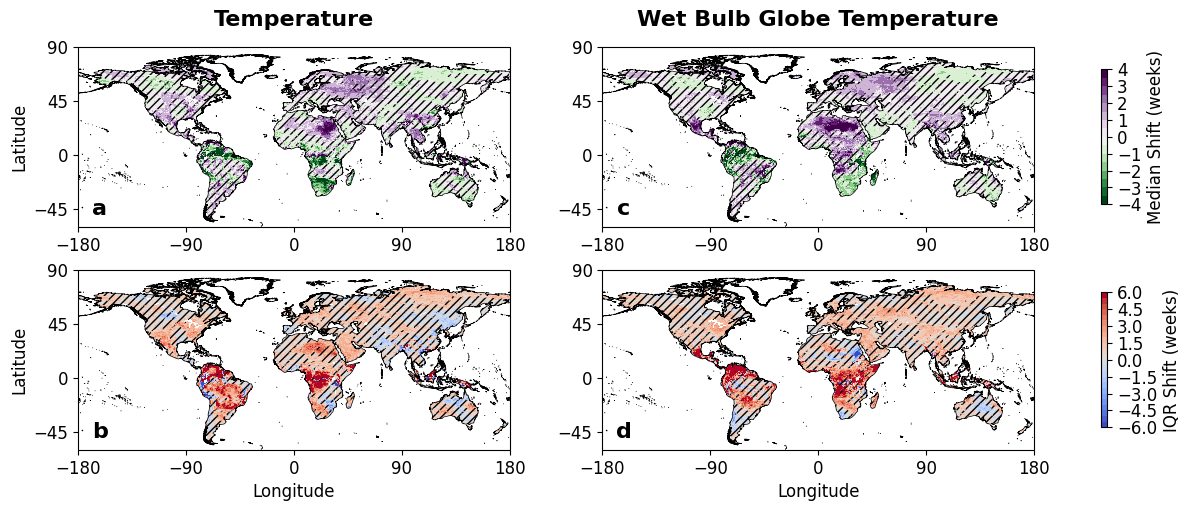

In [13]:
# Plot figures

reg_lats = [-60,90]
reg_lons = [-180,180]

min_sig = 0.05

T95_data = [median_shifts_T95, iqr_shifts_T95]
WBGT95_data = [median_shifts_WBGT95, iqr_shifts_WBGT95]

T95_sig = [median_shifts_pval_T95,iqr_shifts_pval_T95]
WBGT95_sig = [median_shifts_pval_WBGT95,iqr_shifts_pval_WBGT95]

titles = ['Median','IQR']

extremes_datasets = [T95_data,WBGT95_data]
sig_datasets = [T95_sig,WBGT95_sig]
extremes_titles = ['T95','WBGT95']
column_names = ['Temperature','Wet Bulb Globe Temperature']
panel_labels = [['a','b'],['c','d']]

plt.rcParams.update({'font.size': 12})

fig, axs = plt.subplots(2,2, figsize = (12,5),facecolor = 'w', edgecolor = 'k',constrained_layout=True, subplot_kw = {'projection': ccrs.PlateCarree()})

for i, extremes_data in enumerate(extremes_datasets): # i is column number

    sig_data = sig_datasets[i]
    
    for j in range(2): # j is row number

        if j == 0:
            cmap = plt.cm.get_cmap("PRGn_r")
            bounds = np.arange(-4, 4.5, 0.5)
            axs[j,i].text(0.5, 1.15, column_names[i], transform=axs[j,i].transAxes, 
                          fontsize=16, fontweight = 'bold', verticalalignment='center', horizontalalignment='center')
            
        if j == 1:
            axs[j,i].set_xlabel('Longitude')
            cmap = plt.cm.get_cmap("coolwarm")
            bounds = np.arange(-6, 6.5, 0.5)
                
        norm = matplotlib.colors.BoundaryNorm(bounds, cmap.N)
        cmap.set_bad('white',1.)

        # Plot shaded data
        data_masked = extremes_data[j]*mask_array
        mesh = axs[j,i].pcolormesh(frac_land.lon,frac_land.lat,data_masked, norm = norm, cmap = cmap)

        # Plot significance stipping
        sig_mask = (sig_data[j]*mask_array > 0.05)
        conf = axs[j,i].contourf(frac_land.lon, frac_land.lat, sig_mask, hatches=['', '////'], alpha=0)

        # Print out Phoenix value
        #sig_da = xr.DataArray(sig_data[j],
        #                   coords={"lat": T95_days_daily.lat, "lon": T95_days_daily.lon},
        #                   dims=["lat", "lon"]
        #                  )
        #sig_phoenix = sig_da.sel(lat = lat, lon = lon, method = 'nearest')
        #print(extremes_titles[i] + ', ' +titles[j] + ': ' + f'{sig_phoenix.values:0.5f}')

        #axs[j,i].scatter(lon, lat, marker = '*', s = 25, c = 'crimson')
        
        # Plot coastlines and states given cartopy not working
        for shape in coastlines.shapeRecords():
            x = [m[0] for m in shape.shape.points[:]]
            y = [m[1] for m in shape.shape.points[:]]
            axs[j,i].plot(x,y, color = 'k', linewidth = 0.5)
        
        axs[j,i].set_ylim([-60,90])
        axs[j,i].set_yticks([-45,0,45,90])
        axs[j,i].set_xlim([-180,180])
        axs[j,i].set_xticks([-180,-90,0,90,180])
        
        #axs[j,i].set_title(titles[j])

        if i == 1:
            cbar = plt.colorbar(mesh, ax = axs[j,:], orientation = 'vertical',  label = titles[j] + ' Shift (weeks)', shrink = 0.75)
            cbar.ax.minorticks_off()
        if i == 0:
            axs[j,i].set_ylabel('Latitude')

        axs[j,i].text(0.05, 0.1, panel_labels[i][j], transform=axs[j,i].transAxes,
                     fontsize=16, fontweight = 'bold', verticalalignment='center', horizontalalignment='center')

# Presentation Figures (just temperature)

IndexError: too many indices for array: array is 1-dimensional, but 2 were indexed

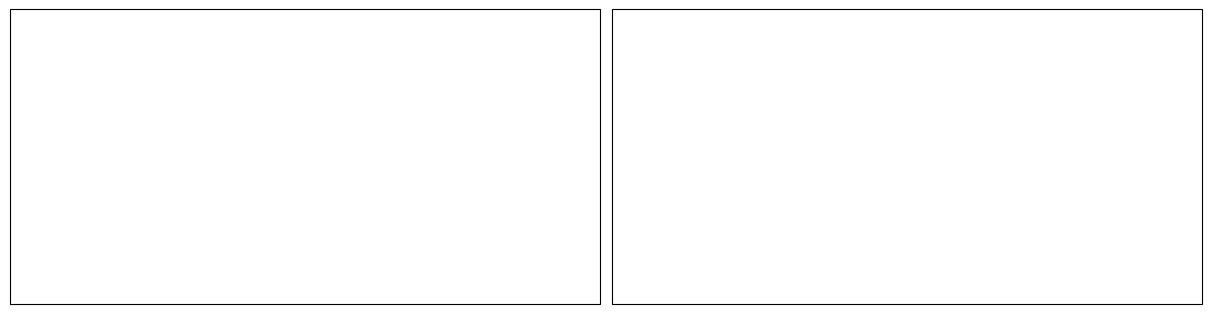

In [12]:
# Plot figures

reg_lats = [-60,90]
reg_lons = [-180,180]

min_sig = 0.05

T95_data = [median_shifts_T95, iqr_shifts_T95]

T95_sig = [median_shifts_pval_T95,iqr_shifts_pval_T95]

titles = ['Median','IQR']

extremes_datasets = [T95_data]
sig_datasets = [T95_sig]
extremes_titles = ['T95']
column_names = ['Temperature']

plt.rcParams.update({'font.size': 12})

fig, axs = plt.subplots(1,2, figsize = (12,5),facecolor = 'w', edgecolor = 'k',constrained_layout=True, subplot_kw = {'projection': ccrs.PlateCarree()})

for i, extremes_data in enumerate(extremes_datasets): # i is row number

    sig_data = sig_datasets[i]
    
    for j in range(1): # j is column

        if j == 0:
            cmap = plt.cm.get_cmap("PRGn_r")
            bounds = np.arange(-4, 4.5, 0.5)
            
        if j == 1:
            axs[i,j].set_xlabel('Longitude')
            cmap = plt.cm.get_cmap("coolwarm")
            bounds = np.arange(-6, 6.5, 0.5)
                
        norm = matplotlib.colors.BoundaryNorm(bounds, cmap.N)
        cmap.set_bad('white',1.)

        # Plot shaded data
        data_masked = extremes_data[j]*mask_array
        mesh = axs[i,j].pcolormesh(frac_land.lon,frac_land.lat,data_masked, norm = norm, cmap = cmap)

        # Plot significance stipping
        sig_mask = (sig_data[j]*mask_array > 0.05)
        conf = axs[i,j].contourf(frac_land.lon, frac_land.lat, sig_mask, hatches=['', '////'], alpha=0)
        
        # Plot coastlines and states given cartopy not working
        for shape in coastlines.shapeRecords():
            x = [m[0] for m in shape.shape.points[:]]
            y = [m[1] for m in shape.shape.points[:]]
            axs[i,j].plot(x,y, color = 'k', linewidth = 0.5)
        
        axs[i,j].set_ylim([-60,90])
        axs[i,j].set_yticks([-45,0,45,90])
        axs[i,j].set_xlim([-180,180])
        axs[i,j].set_xticks([-180,-90,0,90,180])

        cbar = plt.colorbar(mesh, ax = axs[i,j], orientation = 'vertical',  label = titles[j] + ' Shift (weeks)', shrink = 0.75)
        cbar.ax.minorticks_off()
            
        axs[i,j].set_ylabel('Latitude')

### Calculate fraction of grid cells with expanding heat seasons

In [24]:
pval_mask_T95 = np.where(iqr_shifts_pval_T95 < 0.05, 1, np.nan)
pval_mask_WBGT95 = np.where(iqr_shifts_pval_WBGT95 < 0.05, 1, np.nan)

In [29]:
iqr_T95_1D_sig = np.ravel(iqr_shifts_T95*mask_array*pval_mask_T95)
inc_T95 = np.where(iqr_T95_1D_sig > 0, 1, 0)

iqr_T95_1D_all = np.ravel(iqr_shifts_T95*mask_array)
total_T95 = np.where(iqr_T95_1D_all > 0, 1, 0)
frac_inc_T95 = np.sum(inc_T95)/np.sum(total_T95)

In [31]:
iqr_WBGT95_1D_sig = np.ravel(iqr_shifts_WBGT95*mask_array*pval_mask_WBGT95)
inc_WBGT95 = np.where(iqr_WBGT95_1D_sig > 0, 1, 0)

iqr_WBGT95_1D_all = np.ravel(iqr_shifts_WBGT95*mask_array)
total_WBGT95 = np.where(iqr_WBGT95_1D_all > 0, 1, 0)
frac_inc_WBGT95 = np.sum(inc_WBGT95)/np.sum(total_WBGT95)

In [30]:
frac_inc_T95

np.float64(0.5172964738230594)

In [32]:
frac_inc_WBGT95

np.float64(0.5152246110819787)

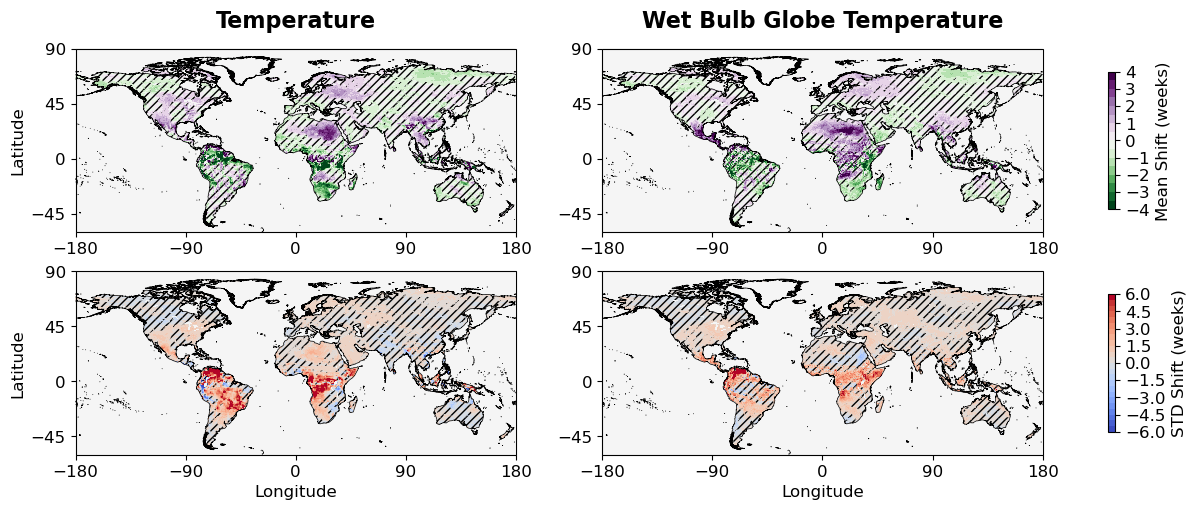

In [19]:
# Plot figures

reg_lats = [-60,90]
reg_lons = [-180,180]

min_sig = 0.05

T95_data = [mean_shifts_T95, std_shifts_T95]
WBGT95_data = [mean_shifts_WBGT95, std_shifts_WBGT95]

T95_sig = [mean_shifts_pval_T95,var_shifts_pval_T95]
WBGT95_sig = [mean_shifts_pval_WBGT95,var_shifts_pval_WBGT95]

titles = ['Mean','STD']

extremes_datasets = [T95_data,WBGT95_data]
sig_datasets = [T95_sig,WBGT95_sig]
extremes_titles = ['T95','WBGT95']
column_names = ['Temperature','Wet Bulb Globe Temperature']

fig, axs = plt.subplots(2,2, figsize = (12,5),facecolor = 'w', edgecolor = 'k',constrained_layout=True, subplot_kw = {'projection': ccrs.PlateCarree()})

for i, extremes_data in enumerate(extremes_datasets): # i is column number

    sig_data = sig_datasets[i]
    
    for j in range(2): # j is row number

        if j == 0:
            cmap = plt.cm.get_cmap("PRGn_r")
            bounds = np.arange(-4, 4.5, 0.5)
            axs[j,i].text(0.5, 1.15, column_names[i], transform=axs[j,i].transAxes, 
                          fontsize=16, fontweight = 'bold', verticalalignment='center', horizontalalignment='center')
            
        if j == 1:
            axs[j,i].set_xlabel('Longitude')
            cmap = plt.cm.get_cmap("coolwarm")
            bounds = np.arange(-6, 6.5, 0.5)
                
        norm = matplotlib.colors.BoundaryNorm(bounds, cmap.N)
        cmap.set_bad('whitesmoke',1.)

        # Plot shaded data
        data_masked = extremes_data[j]*mask_array
        mesh = axs[j,i].pcolormesh(frac_land.lon,frac_land.lat,data_masked, norm = norm, cmap = cmap)

        # Plot significance stipping
        sig_mask = (sig_data[j]*mask_array > 0.05)
        conf = axs[j,i].contourf(frac_land.lon, frac_land.lat, sig_mask, hatches=['', '////'], alpha=0)

        # Plot coastlines and states given cartopy not working
        for shape in coastlines.shapeRecords():
            x = [m[0] for m in shape.shape.points[:]]
            y = [m[1] for m in shape.shape.points[:]]
            axs[j,i].plot(x,y, color = 'k', linewidth = 0.5)
        
        axs[j,i].set_ylim([-60,90])
        axs[j,i].set_yticks([-45,0,45,90])
        axs[j,i].set_xlim([-180,180])
        axs[j,i].set_xticks([-180,-90,0,90,180])
        
        #axs[j,i].set_title(titles[j])

        if i == 1:
            cbar = plt.colorbar(mesh, ax = axs[j,:], orientation = 'vertical',  label = titles[j] + ' Shift (weeks)', shrink = 0.75)
            cbar.ax.minorticks_off()
        if i == 0:
            axs[j,i].set_ylabel('Latitude')

# Bootstrapping

In [15]:
def distribution_shifts_bootstrapping(early_ds,late_ds,var: str):

    # If data exists (not over ocean)
    if np.max(early_ds[var]).isnull() == False:
        
        mean_shifts_randomized = []
        median_shifts_randomized = []
        skew_shifts_randomized = []
        kurtosis_shifts_randomized = []
        
        n = 100
        
        for i in range(n):
        
            # Randomize where in the historical period T95 events occur (with replacement)
            new_early_dataarray = xr.DataArray(
                #np.random.choice(early_ds[var], len(early_ds[var]), replace = True),
                early_ds[var].groupby('time.month').map(resample_with_replacement), 
                coords={'time': early_ds.time},
                dims=['time'],
                name='randomized_counts'
            )
            #new_early_dataarray = early_ds[var].groupby('time.month').map(resample_with_replacement)
            
            early_ds['randomized_counts'] = new_early_dataarray
            
            new_late_dataarray = xr.DataArray(
                #np.random.choice(late_ds[var], len(late_ds[var]), replace = True),
                late_ds[var].groupby('time.month').map(resample_with_replacement),
                coords={'time': late_ds.time},
                dims=['time'],
                name='randomized_counts'
            )

            #new_late_dataarray = late_ds[var].groupby('time.month').map(resample_with_replacement)

            late_ds['randomized_counts'] = new_late_dataarray
        
            # Repeat the calculation methods to measure changes in statistical moments from one period to the next
            early_counts_random = early_ds.where(early_ds.randomized_counts > 0, drop = True).time.dt.week
            late_counts_random = late_ds.where(late_ds.randomized_counts > 0, drop = True).time.dt.week
        
            early_period_random = early_counts_random
            late_period_random = late_counts_random
            peak_period_random = stats.mode(early_period_random.values).mode
        
            if (peak_period_random - peak_period_random) == 0:
        
                # Subtract peak month
                early_period_temp_random = np.array([x - int(peak_period_random) for x in early_period_random.values])
                late_period_temp_random = np.array([x - int(peak_period_random) for x in late_period_random.values])
            
                # Account for annual cycle numbering convention
                early_period_shifted_random = [
                    (x-52) if x > 26 else
                    (x+52) if x < -26 else
                    x
                    for x in early_period_temp_random
                ]
                
                late_period_shifted_random = [
                    (x-52) if x > 26 else
                    (x+52) if x < -26 else
                    x
                    for x in late_period_temp_random
                ]
        
                if (len(early_period_temp_random) > 0) & (len(late_period_temp_random) > 0):
                
                    # Calculate changes in distributions
                    mean_shift_random = np.mean(late_period_shifted_random) - np.mean(early_period_shifted_random)
                    skew_shift_random = stats.skew(late_period_shifted_random) - stats.skew(early_period_shifted_random)
                    kurtosis_shift_random = stats.kurtosis(late_period_shifted_random) - stats.kurtosis(early_period_shifted_random)
                    median_shift_random = np.median(late_period_shifted_random) - np.median(early_period_shifted_random)
        
                    # Calculate statistical moments and add to lists
                    mean_shifts_randomized.append(mean_shift_random)
                    median_shifts_randomized.append(median_shift_random)
                    skew_shifts_randomized.append(skew_shift_random)
                    kurtosis_shifts_randomized.append(kurtosis_shift_random)
    
                else:
                    mean_shift = np.nan
                    median_shift = np.nan
                    skew_shift = np.nan
                    kurtosis_shift = np.nan
                    pvalue = np.nan  
    
            else:
                mean_shift = np.nan
                median_shift = np.nan
                skew_shift = np.nan
                kurtosis_shift = np.nan
                pvalue = np.nan
    
            # Drop variables to clear out
            early_ds = early_ds.drop_vars(['randomized_counts'])
            late_ds = late_ds.drop_vars(['randomized_counts'])
        
        # Calculate confidence intervals
        mean_5 = np.percentile(mean_shifts_randomized, 5)
        mean_95 = np.percentile(mean_shifts_randomized, 95)
        
        median_5 = np.percentile(median_shifts_randomized, 5)
        median_95 = np.percentile(median_shifts_randomized, 95)
        
        skew_5 = np.percentile(skew_shifts_randomized, 5)
        skew_95 = np.percentile(skew_shifts_randomized, 95)
        
        kurtosis_5 = np.percentile(kurtosis_shifts_randomized, 5)
        kurtosis_95 = np.percentile(kurtosis_shifts_randomized, 95)

    else:
        mean_5 = np.nan
        mean_95 = np.nan
        
        median_5 = np.nan
        median_95 = np.nan
        
        skew_5 = np.nan
        skew_95 = np.nan
        
        kurtosis_5 = np.nan
        kurtosis_95 = np.nan
        
    return np.array([mean_5, mean_95, median_5, median_95,skew_5,skew_95,kurtosis_5,kurtosis_95])

In [ ]:
# OLD VERSION
'''
def distribution_shifts_bootstrapping(early_ds,late_ds,var: str):

    # If data exists (not over ocean)
    if np.max(early_ds[var]).isnull() == False:
        
        mean_shifts_randomized = []
        median_shifts_randomized = []
        skew_shifts_randomized = []
        kurtosis_shifts_randomized = []
        
        n = 500
        
        for i in range(n):
        
            # Randomize where in the historical period T95 events occur (with replacement)
            new_early_dataarray = xr.DataArray(
                np.random.choice(early_ds[var], len(early_ds[var]), replace = True),
                coords={'time': early_ds.time},
                dims=['time'],
                name='randomized_counts'
            )
            
            early_ds['randomized_counts'] = new_early_dataarray
            
            new_late_dataarray = xr.DataArray(
                np.random.choice(late_ds[var], len(late_ds[var]), replace = True),
                coords={'time': late_ds.time},
                dims=['time'],
                name='randomized_counts'
            )
            
            late_ds['randomized_counts'] = new_late_dataarray
        
            # Repeat the calculation methods to measure changes in statistical moments from one period to the next
            early_counts_random = early_ds.where(early_ds.randomized_counts > 0, drop = True).time.dt.week
            late_counts_random = late_ds.where(late_ds.randomized_counts > 0, drop = True).time.dt.week
        
            early_period_random = early_counts_random
            late_period_random = late_counts_random
            peak_period_random = stats.mode(early_period_random.values).mode
        
            if (peak_period_random - peak_period_random) == 0:
        
                # Subtract peak month
                early_period_temp_random = np.array([x - int(peak_period_random) for x in early_period_random.values])
                late_period_temp_random = np.array([x - int(peak_period_random) for x in late_period_random.values])
            
                # Account for annual cycle numbering convention
                early_period_shifted_random = [
                    (x-52) if x > 26 else
                    (x+52) if x < -26 else
                    x
                    for x in early_period_temp_random
                ]
                
                late_period_shifted_random = [
                    (x-52) if x > 26 else
                    (x+52) if x < -26 else
                    x
                    for x in late_period_temp_random
                ]
        
                if (len(early_period_temp_random) > 0) & (len(late_period_temp_random) > 0):
                
                    # Calculate changes in distributions
                    mean_shift_random = np.mean(late_period_shifted_random) - np.mean(early_period_shifted_random)
                    skew_shift_random = stats.skew(late_period_shifted_random) - stats.skew(early_period_shifted_random)
                    kurtosis_shift_random = stats.kurtosis(late_period_shifted_random) - stats.kurtosis(early_period_shifted_random)
                    median_shift_random = np.median(late_period_shifted_random) - np.median(early_period_shifted_random)
        
                    # Calculate statistical moments and add to lists
                    mean_shifts_randomized.append(mean_shift_random)
                    median_shifts_randomized.append(median_shift_random)
                    skew_shifts_randomized.append(skew_shift_random)
                    kurtosis_shifts_randomized.append(kurtosis_shift_random)
    
                else:
                    mean_shift = np.nan
                    median_shift = np.nan
                    skew_shift = np.nan
                    kurtosis_shift = np.nan
                    pvalue = np.nan  
    
            else:
                mean_shift = np.nan
                median_shift = np.nan
                skew_shift = np.nan
                kurtosis_shift = np.nan
                pvalue = np.nan
    
            # Drop variables to clear out
            early_ds = early_ds.drop_vars(['randomized_counts'])
            late_ds = late_ds.drop_vars(['randomized_counts'])
        
        # Calculate confidence intervals
        mean_5 = np.percentile(mean_shifts_randomized, 5)
        mean_95 = np.percentile(mean_shifts_randomized, 95)
        
        median_5 = np.percentile(median_shifts_randomized, 5)
        median_95 = np.percentile(median_shifts_randomized, 95)
        
        skew_5 = np.percentile(skew_shifts_randomized, 5)
        skew_95 = np.percentile(skew_shifts_randomized, 95)
        
        kurtosis_5 = np.percentile(kurtosis_shifts_randomized, 5)
        kurtosis_95 = np.percentile(kurtosis_shifts_randomized, 95)

    else:
        mean_5 = np.nan
        mean_95 = np.nan
        
        median_5 = np.nan
        median_95 = np.nan
        
        skew_5 = np.nan
        skew_95 = np.nan
        
        kurtosis_5 = np.nan
        kurtosis_95 = np.nan
        
    return np.array([mean_5, mean_95, median_5, median_95,skew_5,skew_95,kurtosis_5,kurtosis_95])
    '''

## Do this for every grid cell

In [19]:
# Mask out datasets to make it go faster
T95_early_masked = T95_early*mask_array
WBGT95_early_masked = WBGT95_early*mask_array

T95_late_masked = T95_late*mask_array
WBGT95_late_masked = WBGT95_late*mask_array

In [20]:
# Select regional data
region = '20-40N'
lats = [20,40]

T95_early_masked_reg = T95_early_masked.sel(lat = slice(lats[0],lats[1]))
WBGT95_early_masked_reg = WBGT95_early_masked.sel(lat = slice(lats[0],lats[1]))

T95_late_masked_reg = T95_late_masked.sel(lat = slice(lats[0],lats[1]))
WBGT95_late_masked_reg = WBGT95_late_masked.sel(lat = slice(lats[0],lats[1]))

In [ ]:
mean_5_CIs_T95 = np.zeros((np.shape(T95_early_masked_reg)[1],np.shape(T95_early_masked_reg)[2]))
median_5_CIs_T95 = np.zeros((np.shape(T95_early_masked_reg)[1],np.shape(T95_early_masked_reg)[2]))
skew_5_CIs_T95 = np.zeros((np.shape(T95_early_masked_reg)[1],np.shape(T95_early_masked_reg)[2]))
kurtosis_5_CIs_T95 = np.zeros((np.shape(T95_early_masked_reg)[1],np.shape(T95_early_masked_reg)[2]))

mean_95_CIs_T95 = np.zeros((np.shape(T95_early_masked_reg)[1],np.shape(T95_early_masked_reg)[2]))
median_95_CIs_T95 = np.zeros((np.shape(T95_early_masked_reg)[1],np.shape(T95_early_masked_reg)[2]))
skew_95_CIs_T95 = np.zeros((np.shape(T95_early_masked_reg)[1],np.shape(T95_early_masked_reg)[2]))
kurtosis_95_CIs_T95 = np.zeros((np.shape(T95_early_masked_reg)[1],np.shape(T95_early_masked_reg)[2]))
                      
# Loop through grid cells and calculate
for i in tqdm(range(np.shape(T95_early_masked_reg)[1])):
    for j in range(np.shape(T95_early_masked_reg)[2]):

        early_data_gc = T95_early_masked_reg.isel(lat = i, lon = j).to_dataset()
        late_data_gc = T95_late_masked_reg.isel(lat = i, lon = j).to_dataset()

        [mean_5, mean_95, median_5, median_95,skew_5,skew_95,kurtosis_5,kurtosis_95] = distribution_shifts_bootstrapping(early_data_gc,late_data_gc, var = 'T2M')
        
        mean_5_CIs_T95[i,j] = mean_5
        mean_95_CIs_T95[i,j] = mean_95

        median_5_CIs_T95[i,j] = median_5
        median_95_CIs_T95[i,j] = median_95

        skew_5_CIs_T95[i,j] = skew_5
        skew_95_CIs_T95[i,j] = skew_95

        kurtosis_5_CIs_T95[i,j] = kurtosis_5
        kurtosis_95_CIs_T95[i,j] = kurtosis_95

  0%|          | 0/41 [00:00<?, ?it/s]

In [ ]:
# Save these out as text files
save_dir = '/discover/nobackup/civanovi/data/MERRA2/processed_data/npp_project2/'

np.savetxt(save_dir + 'weekly_T95_mean_shift_1980-1989_2015-2024_5thpercentile_CI_' + region + '.txt', mean_5_CIs_T95, delimiter=',')
np.savetxt(save_dir + 'weekly_T95_mean_shift_1980-1989_2015-2024_95thpercentile_CI_' + region + '.txt', mean_95_CIs_T95, delimiter=',')

np.savetxt(save_dir + 'weekly_T95_median_shift_1980-1989_2015-2024_5thpercentile_CI_' + region + '.txt', median_5_CIs_T95, delimiter=',')
np.savetxt(save_dir + 'weekly_T95_median_shift_1980-1989_2015-2024_95thpercentile_CI_' + region + '.txt', median_95_CIs_T95, delimiter=',')

np.savetxt(save_dir + 'weekly_T95_skew_shift_1980-1989_2015-2024_5thpercentile_CI_' + region + '.txt', skew_5_CIs_T95, delimiter=',')
np.savetxt(save_dir + 'weekly_T95_skew_shift_1980-1989_2015-2024_95thpercentile_CI_' + region + '.txt', skew_95_CIs_T95, delimiter=',')

np.savetxt(save_dir + 'weekly_T95_kurtosis_shift_1980-1989_2015-2024_5thpercentile_CI_' + region + '.txt', kurtosis_5_CIs_T95, delimiter=',')
np.savetxt(save_dir + 'weekly_T95_kurtosis_shift_1980-1989_2015-2024_95thpercentile_CI_' + region + '.txt', kurtosis_95_CIs_T95, delimiter=',')

In [ ]:
mean_5_CIs_WBGT95 = np.zeros((np.shape(WBGT95_early)[1],np.shape(WBGT95_early)[2]))
median_5_CIs_WBGT95 = np.zeros((np.shape(WBGT95_early)[1],np.shape(WBGT95_early)[2]))
skew_5_CIs_WBGT95 = np.zeros((np.shape(WBGT95_early)[1],np.shape(WBGT95_early)[2]))
kurtosis_5_CIs_WBGT95 = np.zeros((np.shape(WBGT95_early)[1],np.shape(WBGT95_early)[2]))

mean_95_CIs_WBGT95 = np.zeros((np.shape(WBGT95_early)[1],np.shape(WBGT95_early)[2]))
median_95_CIs_WBGT95 = np.zeros((np.shape(WBGT95_early)[1],np.shape(WBGT95_early)[2]))
skew_95_CIs_WBGT95 = np.zeros((np.shape(WBGT95_early)[1],np.shape(WBGT95_early)[2]))
kurtosis_95_CIs_WBGT95 = np.zeros((np.shape(WBGT95_early)[1],np.shape(WBGT95_early)[2]))
                      
# Loop through grid cells and calculate
for i in tqdm(range(np.shape(WBGT95_early_masked)[1])):
    for j in range(np.shape(WBGT95_early_masked)[2]):

        early_data_gc = WBGT95_early.isel(lat = i, lon = j).to_dataset()
        late_data_gc = WBGT95_late.isel(lat = i, lon = j).to_dataset()

        [mean_5, mean_95, median_5, median_95,skew_5,skew_95,kurtosis_5,kurtosis_95] = distribution_shifts_bootstrapping(early_data_gc,late_data_gc)
        
        mean_5_CIs_WBGT95[i,j] = mean_5
        mean_95_CIs_WBGT95[i,j] = mean_95

        median_5_CIs_WBGT95[i,j] = median_5
        median_95_CIs_WBGT95[i,j] = median_95

        skew_5_CIs_WBGT95[i,j] = skew_5
        skew_95_CIs_WBGT95[i,j] = skew_95

        kurtosis_5_CIs_WBGT95[i,j] = kurtosis_5
        kurtosis_95_CIs_WBGT95[i,j] = kurtosis_95

In [ ]:
# Save these out as text files
save_dir = '/discover/nobackup/civanovi/data/MERRA2/processed_data/npp_project2/'

np.savetxt(save_dir + 'weekly_WBGT95_mean_shift_1980-1989_2015-2024_5thpercentile_CI.txt', mean_5_CIs_WBGT95, delimiter=',')
np.savetxt(save_dir + 'weekly_WBGT95_mean_shift_1980-1989_2015-2024_95thpercentile_CI.txt', mean_95_CIs_WBGT95, delimiter=',')

np.savetxt(save_dir + 'weekly_WBGT95_median_shift_1980-1989_2015-2024_5thpercentile_CI.txt', median_5_CIs_WBGT95, delimiter=',')
np.savetxt(save_dir + 'weekly_WBGT95_median_shift_1980-1989_2015-2024_95thpercentile_CI.txt', median_95_CIs_WBGT95, delimiter=',')

np.savetxt(save_dir + 'weekly_WBGT95_skew_shift_1980-1989_2015-2024_5thpercentile_CI.txt', skew_5_CIs_WBGT95, delimiter=',')
np.savetxt(save_dir + 'weekly_WBGT95_skew_shift_1980-1989_2015-2024_95thpercentile_CI.txt', skew_95_CIs_WBGT95, delimiter=',')

np.savetxt(save_dir + 'weekly_WBGT95_kurtosis_shift_1980-1989_2015-2024_5thpercentile_CI.txt', kurtosis_5_CIs_WBGT95, delimiter=',')
np.savetxt(save_dir + 'weekly_WBGT95_kurtosis_shift_1980-1989_2015-2024_95thpercentile_CI.txt', kurtosis_95_CIs_WBGT95, delimiter=',')

In [11]:
# Confidence intervals
region = '20-40N'
lats = [20,40]

mean_5_CIs_T95 = np.loadtxt(save_dir + 'weekly_T95_mean_shift_1980-1989_2015-2024_5thpercentile_CI_' + region + '.txt', delimiter=',')
mean_95_CIs_T95 = np.loadtxt(save_dir + 'weekly_T95_mean_shift_1980-1989_2015-2024_95thpercentile_CI_' + region + '.txt', delimiter=',')

median_5_CIs_T95 = np.loadtxt(save_dir + 'weekly_T95_median_shift_1980-1989_2015-2024_5thpercentile_CI_' + region + '.txt', delimiter=',')
median_95_CIs_T95 = np.loadtxt(save_dir + 'weekly_T95_median_shift_1980-1989_2015-2024_95thpercentile_CI_' + region + '.txt', delimiter=',')

skew_5_CIs_T95 = np.loadtxt(save_dir + 'weekly_T95_skew_shift_1980-1989_2015-2024_5thpercentile_CI_' + region + '.txt', delimiter=',')
skew_95_CIs_T95 = np.loadtxt(save_dir + 'weekly_T95_skew_shift_1980-1989_2015-2024_95thpercentile_CI_' + region + '.txt', delimiter=',')

kurtosis_5_CIs_T95 = np.loadtxt(save_dir + 'weekly_T95_kurtosis_shift_1980-1989_2015-2024_5thpercentile_CI_' + region + '.txt', delimiter=',')
kurtosis_95_CIs_T95 = np.loadtxt(save_dir + 'weekly_T95_kurtosis_shift_1980-1989_2015-2024_95thpercentile_CI_' + region + '.txt', delimiter=',')

In [ ]:
# Plot figures

reg_lats = [-60,90]
reg_lons = [-180,180]

min_sig = 0.05

T95_data = [mean_shifts_T95,median_shifts_T95, skew_shifts_T95, var_shifts_T95, kurtosis_shifts_T95,pval_shifts_T95]
WBGT95_data = [mean_shifts_WBGT95,median_shifts_WBGT95,skew_shifts_WBGT95, var_shifts_WBGT95, kurtosis_shifts_WBGT95,pval_shifts_WBGT95]

low_CIs = [mean_5_CIs_T95,median_5_CIs_T95,skew_5_CIs_T95,kurtosis_5_CIs_T95]
high_CIs = [mean_95_CIs_T95,median_95_CIs_T95,skew_95_CIs_T95,kurtosis_95_CIs_T95]

titles = ['$\Delta$Mean','$\Delta$Median','$\Delta$Skewness','$\Delta$Variance','$\Delta$Kurtosis']

extremes_datasets = [T95_data,WBGT95_data]
extremes_titles = ['T95','WBGT95']

for j, extremes_data in enumerate(extremes_datasets):

    fig, axs = plt.subplots(2,3, figsize = (12,6),facecolor = 'w', edgecolor = 'k',constrained_layout=True, subplot_kw = {'projection': ccrs.PlateCarree()})
    
    for i, ax in enumerate(fig.axes):

        if i == 5:
            ax.remove()

        else:
            if i == 0:
                ax.set_ylabel('Latitude')
            if i == 1:
                ax.text(0,120, f'Seasonal Distribution of {extremes_titles[j]}: 1980-1989 versus 2015-2024', fontweight = 'bold', horizontalalignment = 'center')
            if i == 3:
                vmin = -12
                vmax = 12
                cmap = plt.cm.get_cmap("coolwarm")
            if i != 3:
                vmin = -4
                vmax = 4
            if i < 3:
                cmap = plt.cm.get_cmap("PRGn_r")
            if i == 4:
                cmap = plt.cm.get_cmap("coolwarm_r")
    
            # Plot shaded data
            data_masked = extremes_data[i]*mask_array
            mesh = ax.pcolormesh(frac_land.lon,frac_land.lat,data_masked, vmin = vmin, vmax = vmax, cmap = cmap)

            if j == 0:

                lowerCI = xr.DataArray(
                    low_CIs[j], 
                    coords={'lat': T95_early_masked_reg.lat, 'lon': T95_early_masked_reg.lon},
                    dims=['lat','lon'],
                )

                upperCI = xr.DataArray(
                    high_CIs[j], 
                    coords={'lat': T95_early_masked_reg.lat, 'lon': T95_early_masked_reg.lon},
                    dims=['lat','lon'],
                )

                data_masked_da = xr.DataArray(
                    data_masked, 
                    coords={'lat': frac_land.lat, 'lon': frac_land.lon},
                    dims=['lat','lon'],
                )
                
                # Plot pvalue hatching
                sig_mask = (data_masked_da.sel(lat = slice(lats[0],lats[1])) < upperCI) + (data_masked_da.sel(lat = slice(lats[0],lats[1])) > lowerCI)
                conf = ax.contourf(upperCI.lon, upperCI.lat, sig_mask, hatches=['', '////'], alpha=0)
    
            # Plot coastlines and states given cartopy not working
            for shape in coastlines.shapeRecords():
                x = [m[0] for m in shape.shape.points[:]]
                y = [m[1] for m in shape.shape.points[:]]
                ax.plot(x,y, color = 'k', linewidth = 0.5)
            
            ax.set_xlim(reg_lons)
            ax.set_ylim(reg_lats)
            ax.set_xticks(reg_lons);
            ax.set_yticks(reg_lats);
            ax.set_xlabel('Longitude')
            ax.set_title(titles[i])
        
            plt.colorbar(mesh, ax = ax, orientation = 'horizontal', shrink = 0.5, label = 'shift between periods')

## Individual Grid Cell

In [31]:
location = 'NEVADA'
lat = 38.7
lon = -115

T95_early_gc = T95_early.sel(lat = lat, lon = lon, method = 'nearest')
T95_late_gc = T95_late.sel(lat = lat, lon = lon, method = 'nearest')

early_counts = T95_early_gc.where(T95_early_gc > 0, drop = True).time.dt.week
late_counts = T95_late_gc.where(T95_late_gc > 0, drop = True).time.dt.week

early_total = early_counts.sum(dim = 'time')
early_frac = early_counts/early_total

late_total = late_counts.sum(dim = 'time')
late_frac = late_counts/late_total

In [32]:
location = 'NEVADA'
lat = 38.7
lon = -115

mid_month_global = mid_month_T_ds

mid_month = int(mid_month_global.sel(lat = lat, lon = lon, method = 'nearest').values)

# Find heat season months
if mid_month == 1:
    heat_season = [12,1,2]
elif mid_month == 12:
    heat_season = [11,12,1]
else:
    heat_season = [mid_month-1,mid_month,mid_month+1]

# Outside months
before_season_temp = [heat_season[0] - 2,heat_season[0] - 1]
after_season_temp = [heat_season[2] + 1,heat_season[2] + 2]

# Adjust if this gives negative numbers
before_season = [x if x > 0  else (x+12) for x in before_season_temp]

after_season = [x if x <= 12 else (x-12) for x in after_season_temp]

heat_season_start_DOY = int(T95_early_gc.sel(time = (T95_early_gc.time.dt.year == 1980) & (T95_early_gc.time.dt.month == min(heat_season))).time.dt.dayofyear[0])
heat_season_end_DOY = int(T95_early_gc.sel(time = (T95_early_gc.time.dt.year == 1980) & (T95_early_gc.time.dt.month == max(heat_season))).time.dt.dayofyear[-1])

before_season_start_DOY = int(T95_early_gc.sel(time = (T95_early_gc.time.dt.year == 1980) & (T95_early_gc.time.dt.month == min(before_season))).time.dt.dayofyear[0])
before_season_end_DOY = int(T95_early_gc.sel(time = (T95_early_gc.time.dt.year == 1980) & (T95_early_gc.time.dt.month == max(before_season))).time.dt.dayofyear[-1])

after_season_start_DOY = int(T95_early_gc.sel(time = (T95_early_gc.time.dt.year == 1980) & (T95_early_gc.time.dt.month == min(after_season))).time.dt.dayofyear[0])
after_season_end_DOY = int(T95_early_gc.sel(time = (T95_early_gc.time.dt.year == 1980) & (T95_early_gc.time.dt.month == max(after_season))).time.dt.dayofyear[-1])

In [33]:
early_period = early_counts
late_period = late_counts
peak_period = stats.mode(early_period.values).mode

In [34]:
# Add shifted time dimension to period data
early_ds = T95_early_gc.to_dataset()
late_ds = T95_late_gc.to_dataset()

In [15]:
#randomized_da = early_ds.T2M.groupby('time.month').map(resample_with_replacement)

In [38]:
[mean_5, mean_95, median_5, median_95,skew_5,skew_95,kurtosis_5,kurtosis_95] = distribution_shifts_bootstrapping(early_ds,late_ds, var = 'T2M')

In [126]:
if (peak_period - peak_period) == 0:

    # Subtract peak month
    early_period_temp = np.array([x - int(peak_period) for x in early_period.values])
    late_period_temp = np.array([x - int(peak_period) for x in late_period.values])

    # Account for annual cycle numbering convention
    early_period_shifted = [
        (x-52) if x > 26 else
        (x+52) if x < -26 else
        x
        for x in early_period_temp
    ]
    
    late_period_shifted = [
        (x-52) if x > 26 else
        (x+52) if x < -26 else
        x
        for x in late_period_temp
    ]

    if (len(early_period_temp) > 0) & (len(late_period_temp) > 0):
    
        # Calculate changes in distributions
        mean_shift = np.mean(late_period_shifted) - np.mean(early_period_shifted)
        skew_shift = stats.skew(late_period_shifted) - stats.skew(early_period_shifted)
        kurtosis_shift = stats.kurtosis(late_period_shifted) - stats.kurtosis(early_period_shifted)
        median_shift = np.median(late_period_shifted) - np.median(early_period_shifted)

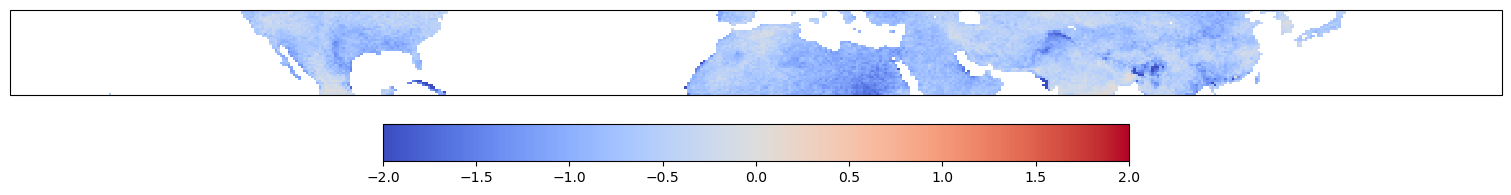

In [70]:
fig, axs = plt.subplots(1,1, figsize = (15,6),facecolor = 'w', edgecolor = 'k',constrained_layout=True, subplot_kw = {'projection': ccrs.PlateCarree()})

mesh = axs.pcolormesh(upperCI.lon, upperCI.lat, data_masked_da.sel(lat = slice(lats[0],lats[1])) - upperCI, cmap = 'coolwarm', vmin = -2, vmax = 2)
plt.colorbar(mesh, orientation = 'horizontal', shrink = 0.5)

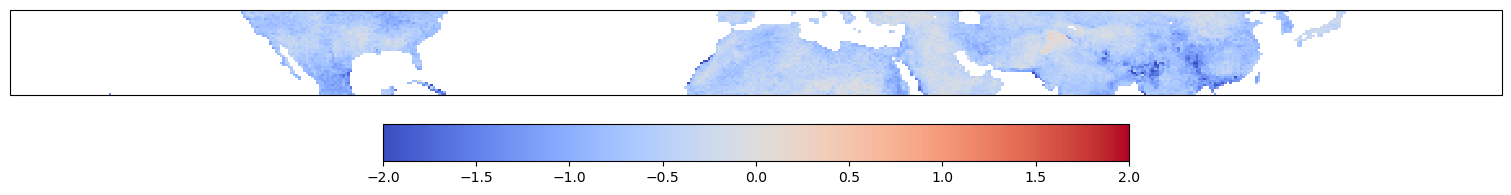

In [71]:
fig, axs = plt.subplots(1,1, figsize = (15,6),facecolor = 'w', edgecolor = 'k',constrained_layout=True, subplot_kw = {'projection': ccrs.PlateCarree()})

mesh = axs.pcolormesh(lowerCI.lon, lowerCI.lat, lowerCI - data_masked_da.sel(lat = slice(lats[0],lats[1])), cmap = 'coolwarm', vmin = -2, vmax = 2)
plt.colorbar(mesh, orientation = 'horizontal', shrink = 0.5)

# OLDDDDD

In [ ]:
early_total = early_counts.sum(dim = 'time')
early_weekly = weekly_sum(T95_early_gc)

late_total = late_counts.sum(dim = 'time')
late_weekly = weekly_sum(T95_late_gc)

In [50]:
early_period = early_weekly.groupby('time.dayofyear').sum()
late_period = late_weekly.groupby('time.dayofyear').sum()

In [76]:
peak_inds = early_period[early_period == np.max(early_period)]
num_peaks = len(peak_inds)

# If there is one week with a peak number of events, that's the peak period
if num_peaks == 1:
    peak_period = int(peak_inds.dayofyear)
# If there are multiple weeks tied for peak number of events, take mean across day number
elif num_peaks > 1:
    peak_period = np.mean(peak_inds.dayofyear)

In [78]:
# Only do this where it works
if (peak_period - peak_period) == 0:

    # Subtract peak date
    early_period_temp = np.array([x - int(peak_period) for x in early_period.dayofyear]) # or mid_month_T95_gc, mid_month_WBGT95_gc
    late_period_temp = np.array([x - int(peak_period) for x in late_period.dayofyear])

    # Account for annual cycle numbering convention
    shift = 366
    mid = 183

    early_period_shifted = [
        (x-shift) if x > mid else
        (x+shift) if x < -1*mid else
        x
        for x in early_period_temp
    ]
    
    late_period_shifted = [
        (x-shift) if x > mid else
        (x+shift) if x < -1*mid else
        x
        for x in late_period_temp
    ]

In [ ]:
early_weekly_ds = early_weekly_ds.assign(shifted_dayofyear = early_period_shifted)
late_weekly_ds = late_weekly_ds.assign(shifted_dayofyear = late_period_shifted)